How the student's performance (test score) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
#warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

Becouse the dataset does not include a unique code for each student, we cannot guarantee that the identical rows represent duplicate records rather than different students with the same characteristics.

In [11]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [8]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [10]:
#Total Score and Average
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3

In [12]:
reading_full = (df['reading_score'] == 100).sum()
writing_full = (df['writing_score'] == 100).sum()
math_full = (df['math_score'] == 100).sum()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [13]:
reading_less_20 = (df['reading_score'] <= 20).sum()
writing_less_20 = (df['writing_score'] <= 20).sum()
math_less_20 = (df['math_score'] <= 20).sum()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


Insights
- Students have performed the worst in Maths
- Best performance is in reading section

Text(0.5, 1.0, 'Distribution of Average Score by Gender')

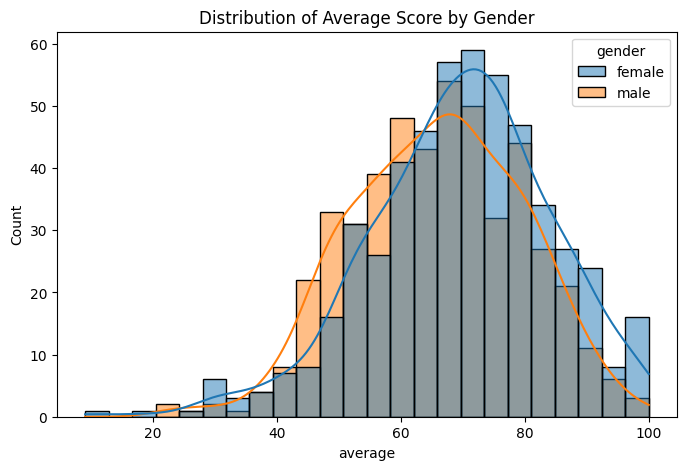

In [19]:
plt.figure(figsize = (8, 5))
sns.histplot(
    data = df,
    x = 'average',
    hue = 'gender',
    kde = True
)
plt.title("Distribution of Average Score by Gender")

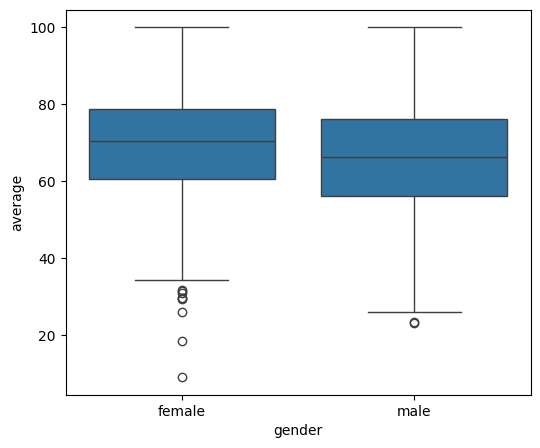

In [21]:
plt.figure(figsize = (6,5))
sns.boxplot(
    data = df,
    x = 'gender',
    y = 'average'
)
plt.show()

The histogram and boxplot show that female students have a higher median average score than male students. Female students present a greater number of lower outliers than male students, but remain valid results and were therefore retained in the analysis.

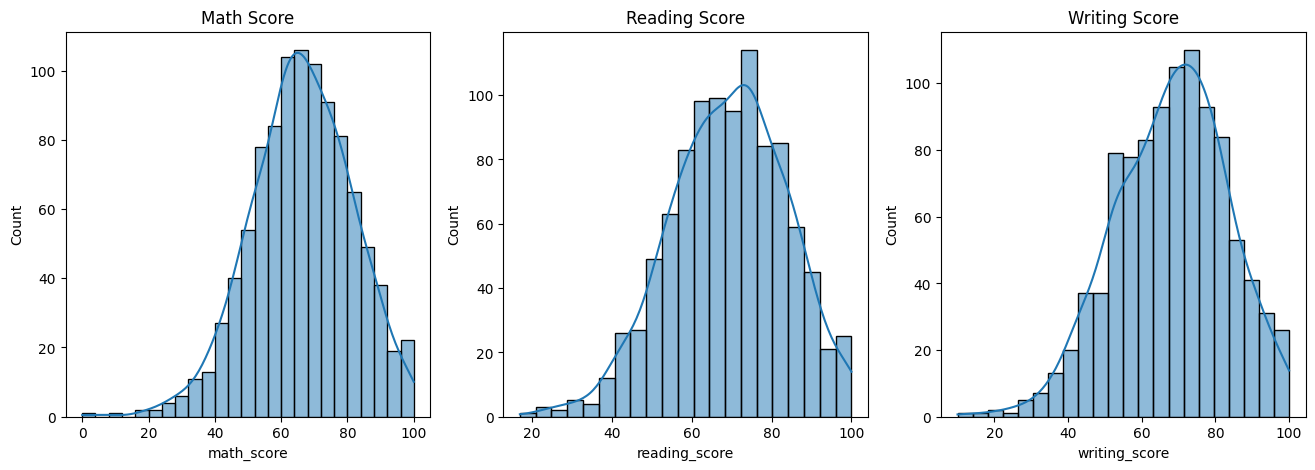

In [22]:
fig, axes = plt.subplots(1,3, figsize=(16,5))

sns.histplot(df["math_score"], kde=True, ax=axes[0])
axes[0].set_title("Math Score")

sns.histplot(df["reading_score"], kde=True, ax=axes[1])
axes[1].set_title("Reading Score")

sns.histplot(df["writing_score"], kde=True, ax=axes[2])
axes[2].set_title("Writing Score")

plt.show()

Students scores are approximately normally distributed, eith most values concentrated between 60 and 80.

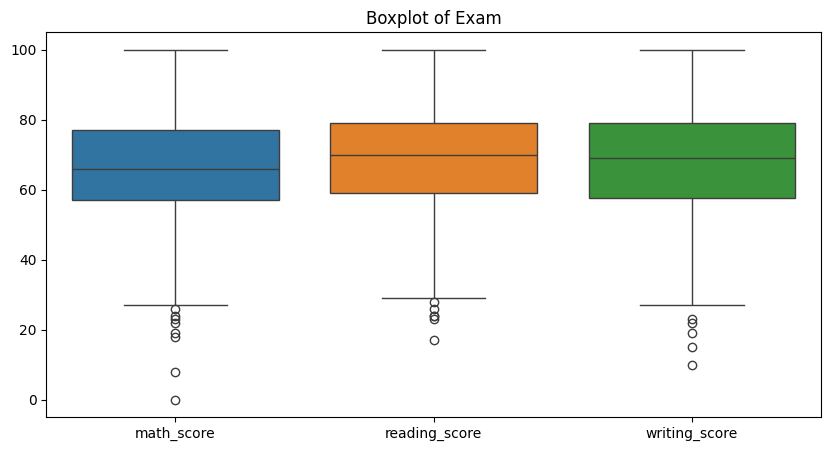

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data = df[["math_score", "reading_score", "writing_score"]]
)
plt.title("Boxplot of Exam")
plt.show()

There are a small number of outliers, math_score having the most. Since these values are plausible exam scores, they were retained.

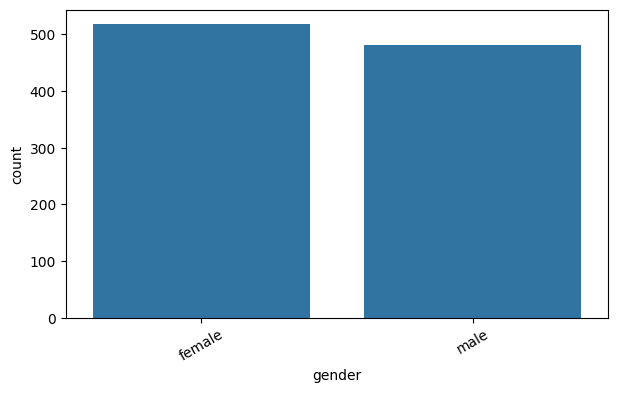

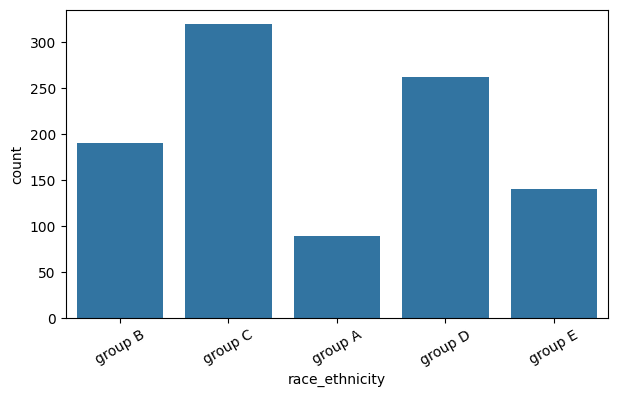

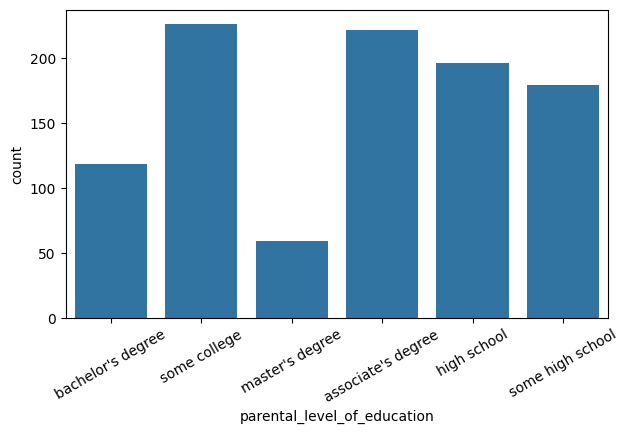

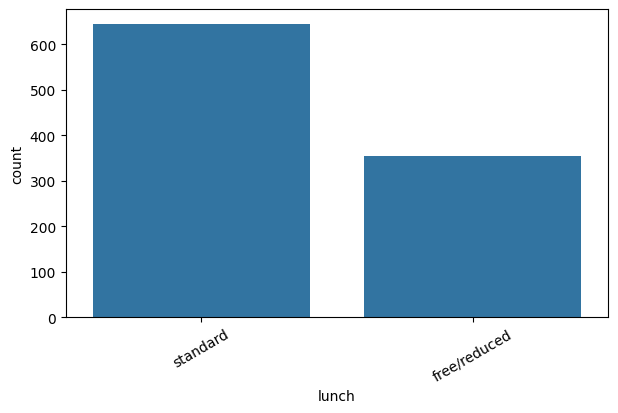

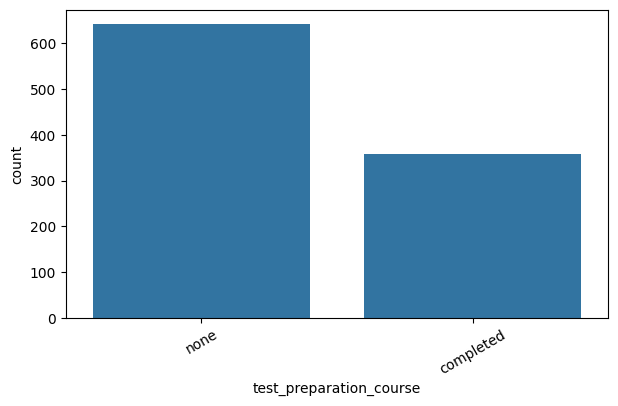

In [29]:
categorical_columns = [
    "gender",
    "race_ethnicity",
    "parental_level_of_education",
    "lunch",
    "test_preparation_course"
]

for col in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(data=df, x=col)

    plt.xticks(rotation=30)

    plt.show()

The categorical variables are not evenly distributed across all categories. While the gender ditribution is relatively balenced, the rest show noticeable differences in the number of observations. These imbalances should be considered when interpreting the results.

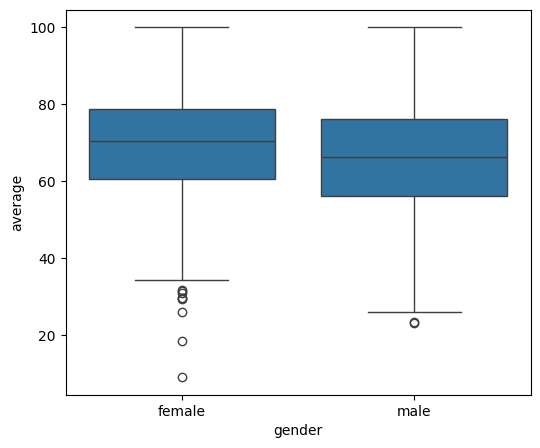

gender
female    69.569498
male      65.837483
Name: average, dtype: float64

In [32]:
plt.figure(figsize = (6,5))

sns.boxplot(
    data = df,
    x = "gender",
    y = "average"
)

plt.show()
df.groupby("gender")["average"].mean()

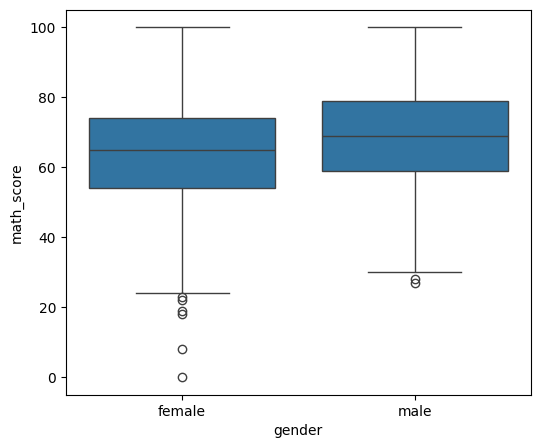

gender
female    63.633205
male      68.728216
Name: math_score, dtype: float64

In [33]:
plt.figure(figsize = (6,5))

sns.boxplot(
    data = df,
    x = "gender",
    y = "math_score"
)

plt.show()
df.groupby("gender")["math_score"].mean()

Female students have a higher average score than male students, primarily due to stronger reading and writing performance. Male students, however,achive higher scores in mathematics.

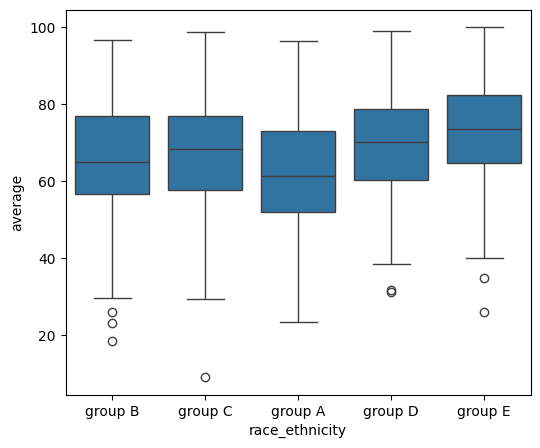

race_ethnicity
group A    62.992509
group B    65.468421
group C    67.131661
group D    69.179389
group E    72.752381
Name: average, dtype: float64

In [34]:
plt.figure(figsize = (6,5))

sns.boxplot(
    data = df,
    x = "race_ethnicity",
    y = "average"
)

plt.show()
df.groupby("race_ethnicity")["average"].mean()

Differances in average performance exist across ethnic groups. 

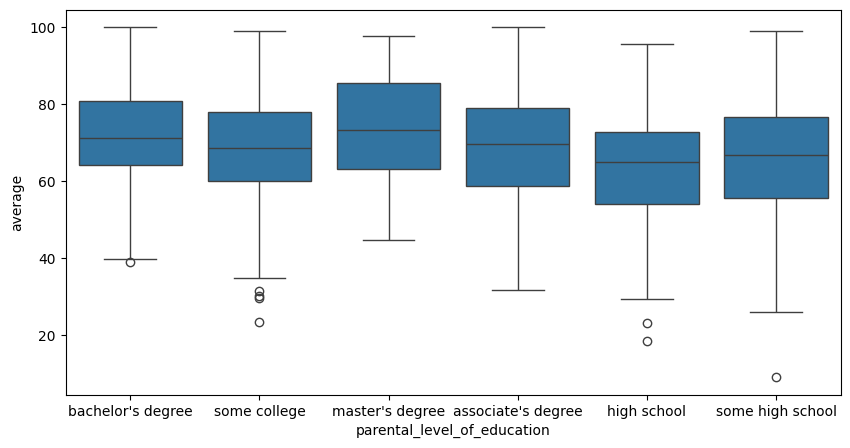

parental_level_of_education
associate's degree    69.569069
bachelor's degree     71.923729
high school           63.096939
master's degree       73.598870
some college          68.476401
some high school      65.108007
Name: average, dtype: float64

In [36]:
plt.figure(figsize = (10,5))

sns.boxplot(
    data = df,
    x = "parental_level_of_education",
    y = "average"
)

plt.show()
df.groupby("parental_level_of_education")["average"].mean()

Students whose parents have higher educational attainment tend to achive higher average scores

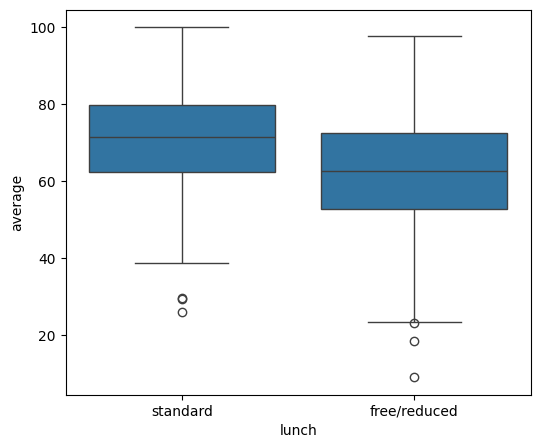

lunch
free/reduced    62.199061
standard        70.837209
Name: average, dtype: float64

In [37]:
plt.figure(figsize = (6,5))

sns.boxplot(
    data = df,
    x = "lunch",
    y = "average"
)

plt.show()
df.groupby("lunch")["average"].mean()

Students receiving the standard lunch generally achive higher scores than students receiving free or reduced lunch

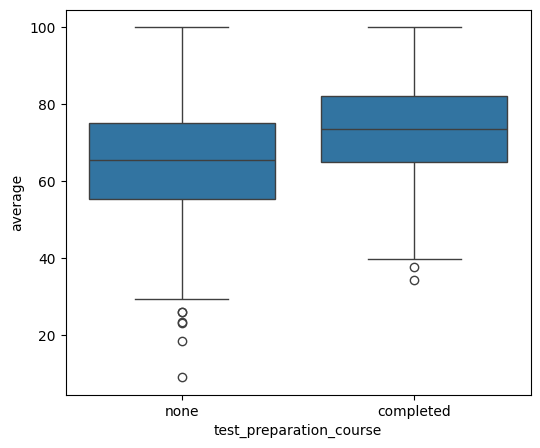

test_preparation_course
completed    72.669460
none         65.038941
Name: average, dtype: float64

In [38]:
plt.figure(figsize = (6,5))

sns.boxplot(
    data = df,
    x = "test_preparation_course",
    y = "average"
)

plt.show()
df.groupby("test_preparation_course")["average"].mean()

Students who completed the test preparation course tend to have higher results than students who didn't completed.

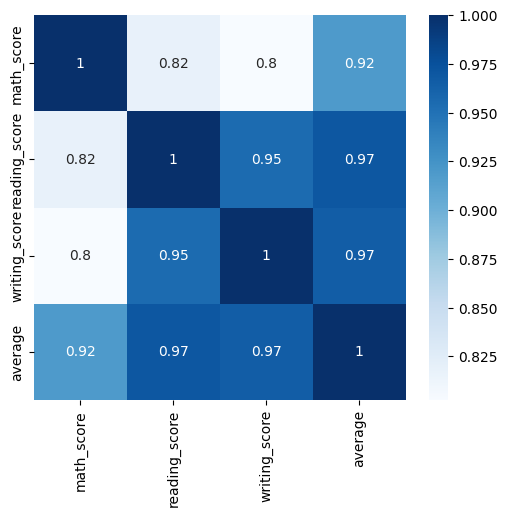

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[[ 
        "math_score",
        "reading_score",
        "writing_score",
        "average"
    ]].corr(),
    annot=True,
    cmap="Blues"
)

plt.show()

Strong positive correlations exist between math, reading, writing, and average score. Reading and writing exhibit the strongest relationship, indicating that students performing well in one subject tend to perform well in the other.